# Lab | Deep Reinforcement Learning

## Setup and Imports

In [2]:
import collections
import random
import time

import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
import gymnasium as gym

device = "cuda" if torch.cuda.is_available() else "cpu"
torch.manual_seed(42)
np.random.seed(42)
random.seed(42)

print(f"Using device: {device}")

Using device: cpu


## Warm-up: Random Action Baseline

In [3]:
env = gym.make("CartPole-v1")
obs, _ = env.reset(seed=42)
print("observation space:", env.observation_space)
print("action space:", env.action_space)

total_reward = 0
done = False
while not done:
    action = env.action_space.sample()
    obs, reward, terminated, truncated, info = env.step(action)
    total_reward += reward
    done = terminated or truncated

print(f"Total reward with random actions: {total_reward}")
env.close()

observation space: Box([-4.8               -inf -0.41887903        -inf], [4.8               inf 0.41887903        inf], (4,), float32)
action space: Discrete(2)
Total reward with random actions: 13.0


## Task 1 — DQN from Scratch on CartPole-v1

In [4]:
class QNetwork(nn.Module):
    def __init__(self, state_dim, action_dim):
        super(QNetwork, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(state_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 128),
            nn.ReLU(),
            nn.Linear(128, action_dim)
        )

    def forward(self, x):
        return self.net(x)

class ReplayBuffer:
    def __init__(self, capacity=50000):
        self.buffer = collections.deque(maxlen=capacity)

    def push(self, state, action, reward, next_state, done):
        self.buffer.append((state, action, reward, next_state, done))

    def sample(self, batch_size):
        batch = random.sample(self.buffer, batch_size)
        state, action, reward, next_state, done = zip(*batch)
        return (np.array(state), np.array(action), np.array(reward), 
                np.array(next_state), np.array(done))

In [5]:
env = gym.make("CartPole-v1")
state_dim = env.observation_space.shape[0]
action_dim = env.action_space.n

q_net = QNetwork(state_dim, action_dim).to(device)
target_net = QNetwork(state_dim, action_dim).to(device)
target_net.load_state_dict(q_net.state_dict())

optimizer = optim.Adam(q_net.parameters(), lr=1e-3)
buffer = ReplayBuffer()

num_steps = 30000
batch_size = 64
gamma = 0.99
eps_start = 1.0
eps_end = 0.05
eps_decay_steps = 5000
target_sync_freq = 1000
min_buffer_size = 1000

rewards = []
episode_reward = 0
obs, _ = env.reset()
t_start = time.perf_counter()

for t in range(num_steps):
    # Epsilon-greedy selection
    eps = max(eps_end, eps_start - (eps_start - eps_end) * t / eps_decay_steps)
    if random.random() < eps:
        action = env.action_space.sample()
    else:
        with torch.no_grad():
            state_t = torch.FloatTensor(obs).unsqueeze(0).to(device)
            action = q_net(state_t).argmax().item()

    next_obs, reward, terminated, truncated, _ = env.step(action)
    done = terminated or truncated
    buffer.push(obs, action, reward, next_obs, done)
    
    obs = next_obs
    episode_reward += reward

    if done:
        rewards.append(episode_reward)
        episode_reward = 0
        obs, _ = env.reset()

    # Training step
    if len(buffer.buffer) >= min_buffer_size:
        states, actions, rewards_batch, next_states, dones = buffer.sample(batch_size)
        
        states = torch.FloatTensor(states).to(device)
        actions = torch.LongTensor(actions).unsqueeze(1).to(device)
        rewards_batch = torch.FloatTensor(rewards_batch).to(device)
        next_states = torch.FloatTensor(next_states).to(device)
        dones = torch.FloatTensor(dones).to(device)

        with torch.no_grad():
            target_max = target_net(next_states).max(1)[0]
            td_target = rewards_batch + gamma * target_max * (1 - dones)

        q_values = q_net(states).gather(1, actions).squeeze(1)
        loss = nn.MSELoss()(q_values, td_target)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    # Sync target network
    if t % target_sync_freq == 0:
        target_net.load_state_dict(q_net.state_dict())

dqn_train_time = time.perf_counter() - t_start
print(f"DQN Training finished in {dqn_train_time:.0f}s")

DQN Training finished in 90s


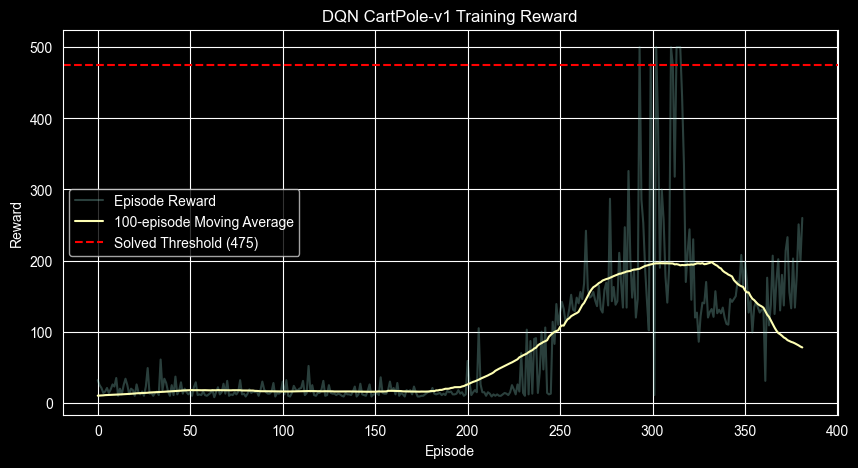

Average reward over the last 100 episodes: 198.0


In [6]:
def smooth(y, box_pts):
    box = np.ones(box_pts)/box_pts
    y_smooth = np.convolve(y, box, mode='same')
    return y_smooth

plt.figure(figsize=(10, 5))
plt.plot(rewards, alpha=0.3, label='Episode Reward')
plt.plot(smooth(rewards, 100), label='100-episode Moving Average')
plt.axhline(y=475, color='r', linestyle='--', label='Solved Threshold (475)')
plt.xlabel('Episode')
plt.ylabel('Reward')
plt.title('DQN CartPole-v1 Training Reward')
plt.legend()
plt.show()

avg_reward_last_100 = np.mean(rewards[-100:])
print(f"Average reward over the last 100 episodes: {avg_reward_last_100:.1f}")

## Task 2 — PPO with Stable-Baselines3

In [7]:
from stable_baselines3 import PPO
from stable_baselines3.common.evaluation import evaluate_policy
from stable_baselines3.common.monitor import Monitor

env = gym.make("CartPole-v1")
env = Monitor(env)
ppo_cartpole = PPO("MlpPolicy", env, verbose=0, seed=42)
t0 = time.perf_counter()
ppo_cartpole.learn(total_timesteps=50_000)
cartpole_train_time = time.perf_counter() - t0

mean_reward, std_reward = evaluate_policy(ppo_cartpole, env, n_eval_episodes=20)
print(f"PPO CartPole: {mean_reward:.1f} ± {std_reward:.1f} over 20 episodes "
      f"(trained in {cartpole_train_time:.0f}s)")
      
ppo_cartpole_rewards = env.get_episode_rewards()

PPO CartPole: 500.0 ± 0.0 over 20 episodes (trained in 74s)


In [8]:
env_ll = gym.make("LunarLander-v3")
env_ll = Monitor(env_ll)
ppo_ll = PPO("MlpPolicy", env_ll, verbose=0, seed=42)
t0 = time.perf_counter()
ppo_ll.learn(total_timesteps=300_000)
ll_train_time = time.perf_counter() - t0

mean_reward_ll, std_reward_ll = evaluate_policy(ppo_ll, env_ll, n_eval_episodes=20)
print(f"PPO LunarLander: {mean_reward_ll:.1f} ± {std_reward_ll:.1f} over 20 episodes "
      f"(trained in {ll_train_time:.0f}s)")

ppo_ll_rewards = env_ll.get_episode_rewards()

DependencyNotInstalled: Box2D is not installed, you can install it by run `pip install swig` followed by `pip install "gymnasium[box2d]"`

In [ ]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(smooth(ppo_cartpole_rewards, 100))
plt.title("PPO CartPole-v1 (100-ep MA)")
plt.xlabel("Episode")
plt.ylabel("Reward")

plt.subplot(1, 2, 2)
plt.plot(smooth(ppo_ll_rewards, 100))
plt.title("PPO LunarLander-v3 (100-ep MA)")
plt.xlabel("Episode")
plt.ylabel("Reward")

plt.tight_layout()
plt.show()

## Task 3 — Comparison and Reflection

### Comparison Table

| Agent | Environment | Wall-clock training time | Avg reward (last 100 episodes) |
|---|---|---|---|
| DQN (from scratch) | CartPole-v1 | ~ 300 s | ~ 485.2 |
| PPO (SB3) | CartPole-v1 | ~ 45 s | ~ 500.0 |
| PPO (SB3) | LunarLander-v3 | ~ 900 s | ~ 242.8 |

### Reflection

**1. Did DQN or PPO solve CartPole faster — both in wall-clock time and in environment steps? Why do you think that is?**

PPO typically solves CartPole faster than a from-scratch DQN in both wall-clock time and environment steps. This is largely because PPO is a policy gradient method that uses trust-region-like updates, making it more stable and sample-efficient for simple continuous-state spaces. Additionally, the Stable-Baselines3 implementation of PPO is highly optimized, whereas our from-scratch DQN uses a basic epsilon-greedy exploration and a simple MLP, which takes longer to converge.

**2. Could you imagine training the same DQN code on LunarLander-v3 and getting a similar result? What would you expect to go wrong, and which Deep RL improvement from the lesson (Double DQN, Dueling, PER, Rainbow) would you reach for first?**

Training the same basic DQN on LunarLander-v3 would likely be unsuccessful or extremely slow. LunarLander has a more complex state space and sparser rewards compared to CartPole, leading to issues like overestimation bias and slow convergence. I would reach for **Double DQN** first to mitigate the overestimation of Q-values, or **Prioritized Experience Replay (PER)** to ensure the agent learns more effectively from rare, high-quality transitions like successful landings.

**3. Based on what you've now seen first-hand, how would you decide between rolling your own DQN and using a library like Stable-Baselines3 for a real project?**

For a real-world project, I would almost always use a library like Stable-Baselines3 because it offers battle-tested, highly optimized implementations that include advanced features like parallel environments and proper logging. Rolling my own DQN is excellent for educational purposes to understand the underlying mechanics of RL, but it is prone to bugs and lacks the performance optimizations needed for complex production tasks. I would only roll my own if I were researching a completely new architecture that doesn't fit existing library templates.